    QBER |   Key rate |  Analítico |          Δ
------------------------------------------------
  0.0000  |   0.499998 |   0.500000 |   2.05e-06
  0.0024  |   0.475228 |   0.475230 |   2.03e-06
  0.0049  |   0.455364 |   0.455366 |   2.03e-06
  0.0073  |   0.437358 |   0.437360 |   2.02e-06
  0.0098  |   0.420561 |   0.420563 |   2.02e-06
  0.0122  |   0.404665 |   0.404667 |   2.02e-06
  0.0147  |   0.389490 |   0.389492 |   2.02e-06
  0.0171  |   0.374915 |   0.374917 |   2.02e-06
  0.0196  |   0.360855 |   0.360857 |   2.02e-06
  0.0220  |   0.347247 |   0.347249 |   2.02e-06
  0.0245  |   0.334041 |   0.334043 |   2.02e-06
  0.0269  |   0.321198 |   0.321200 |   2.02e-06
  0.0294  |   0.308686 |   0.308688 |   2.02e-06
  0.0318  |   0.296477 |   0.296479 |   2.02e-06
  0.0343  |   0.284549 |   0.284551 |   2.02e-06
  0.0367  |   0.272883 |   0.272885 |   2.02e-06
  0.0392  |   0.261461 |   0.261463 |   2.02e-06
  0.0416  |   0.250270 |   0.250272 |   2.02e-06
  0.0441  |   0.23929

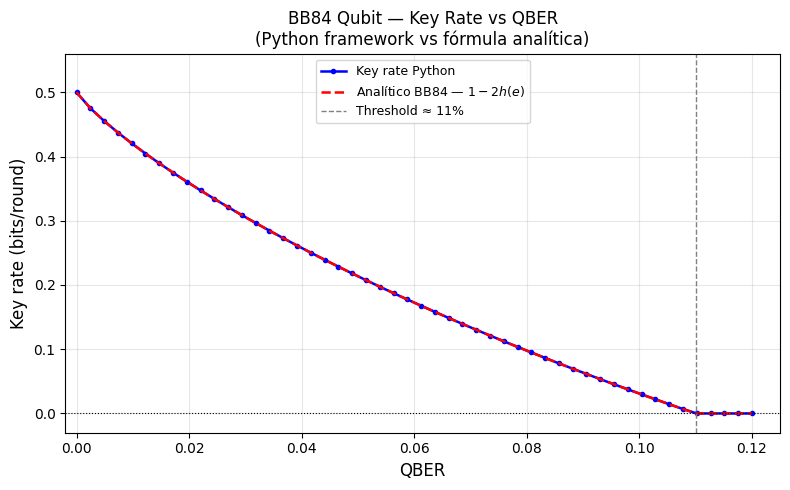


→ bb84_theory.csv e bb84_theory.png exportados
→ Erro máximo vs analítico: 2.05e-06  ✅


In [1]:
import sys, numpy as np
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")
from openqkd.presets.bb84_preset      import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration
import matplotlib.pyplot as plt, csv

def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic(qber, pz=0.5):
    s = pz**2 + (1 - pz)**2
    return max(0.0, s * (1 - 2 * h(qber)))

# ── range:50 points ──────────────────────────────────
qber_range = np.linspace(0, 0.12, 50)
rows = []

print(f"{'QBER':>8} | {'Key rate':>10} | {'Analítico':>10} | {'Δ':>10}")
print("-" * 48)
for qber in qber_range:
    r  = MainIteration(BasicBB84Alice2DPreset(error_rate=float(qber), pz=0.5))
    an = bb84_analytic(float(qber))
    rows.append({
        "qber":        round(float(qber), 6),
        "key_rate":    round(r["key_rate"],    8),
        "lower_bound": round(r["lower_bound"], 8),
        "leak_ec":     round(r["leak_ec"],     8),
        "analytic":    round(an,               8),
        "delta":       round(abs(r["key_rate"] - an), 8),
    })
    print(f"  {qber:.4f}  | {r['key_rate']:>10.6f} | {an:>10.6f} | {abs(r['key_rate']-an):>10.2e}")

with open("bb84_theory.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader(); w.writerows(rows)

# ── Plot ──────────────────────────────────────────────────────────────────
er = [r["qber"]     for r in rows]
kp = [r["key_rate"] for r in rows]
an = [r["analytic"] for r in rows]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(er, kp, "b-o", ms=3, lw=1.8, label="Key rate Python")
ax.plot(er, an, "r--",       lw=1.8, label="Analítico BB84 — $1 - 2h(e)$")
ax.axhline(0,    color="k",    ls=":",  lw=0.8)
ax.axvline(0.11, color="gray", ls="--", lw=1, label="Threshold ≈ 11%")
ax.set_xlabel("QBER", fontsize=12)
ax.set_ylabel("Key rate (bits/round)", fontsize=12)
ax.set_title("BB84 Qubit — Key Rate vs QBER\n(Python framework vs fórmula analítica)", fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(-0.002, 0.125); ax.set_ylim(-0.03, 0.56)
plt.tight_layout()
plt.savefig("bb84_theory.png", dpi=150)
plt.show()


max_d = max(r["delta"] for r in rows if r["analytic"] > 0)
print(f"\n→ bb84_theory.csv e bb84_theory.png exportados")
print(f"→ Erro máximo vs analítico: {max_d:.2e}  {'✅' if max_d < 1e-4 else '⚠️'}")


  depol |  Python KR |  Analítico
------------------------------------
  0.0000 |   0.499998 |   0.500000
  0.0220 |   0.412646 |   0.412648
  0.0440 |   0.347471 |   0.347473
  0.0660 |   0.290778 |   0.290780
  0.0880 |   0.239657 |   0.239659
  0.1100 |   0.192730 |   0.192732
  0.1320 |   0.149182 |   0.149184
  0.1540 |   0.108479 |   0.108481
  0.1760 |   0.070239 |   0.070241
  0.1980 |   0.034180 |   0.034182
  0.2200 |   0.000082 |   0.000084


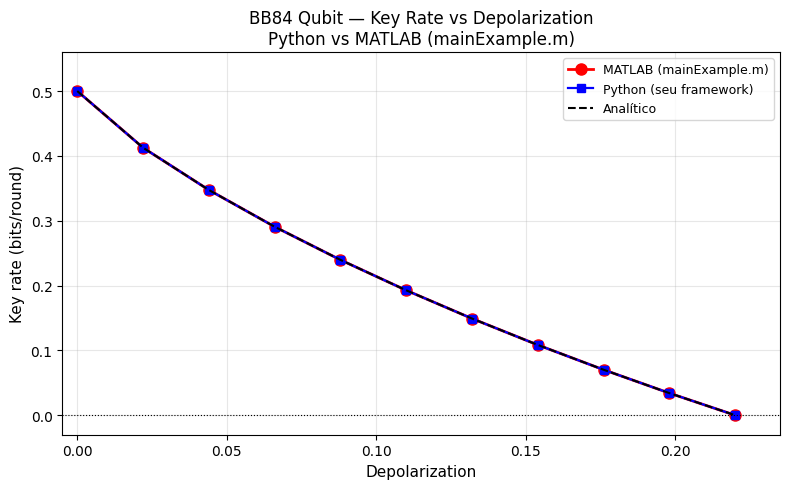

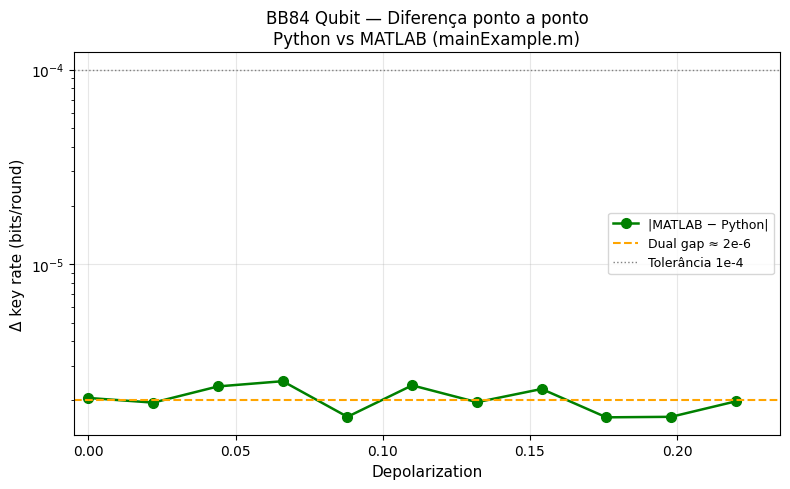

→ bb84_benchmark_curves.png e bb84_benchmark_delta.png exportados
→ Erro máximo: 2.50e-06  ✅


In [3]:
import sys, numpy as np
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")
from openqkd.presets.bb84_preset      import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration
import matplotlib.pyplot as plt, csv

def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic(qber, pz=0.5):
    s = pz**2 + (1 - pz)**2
    return max(0.0, s * (1 - 2 * h(qber)))

# ── Resultados MATLAB — 11 pontos originais do mainExample.m ─────────────
matlab_pts = {
    0.000: 0.500000, 0.022: 0.412648, 0.044: 0.347473,
    0.066: 0.290780, 0.088: 0.239659, 0.110: 0.192732,
    0.132: 0.149184, 0.154: 0.108481, 0.176: 0.070241,
    0.198: 0.034182, 0.220: 0.000084,
}

# ── 22 pontos Python (dobro dos 11 do MATLAB) ─────────────────────────────
depol_range = np.linspace(0, 0.22, 11)
rows = []

print(f"{'depol':>7} | {'Python KR':>10} | {'Analítico':>10}")
print("-" * 36)
for d in depol_range:
    r  = MainIteration(BasicBB84Alice2DPreset(depolarization=float(d), pz=0.5))
    an = bb84_analytic(float(d) / 2)
    rows.append({
        "depolarization": round(float(d), 6),
        "qber":           round(float(d) / 2, 6),
        "python_kr":      round(r["key_rate"],    8),
        "lower_bound":    round(r["lower_bound"], 8),
        "analytic":       round(an,               8),
    })
    print(f"  {d:.4f} | {r['key_rate']:>10.6f} | {an:>10.6f}")

with open("bb84_matlab_benchmark.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader(); w.writerows(rows)

# ── Plot 1: curvas sobrepostas ────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(dp_m, kr_m,  "r-o", ms=8,  lw=2,   label="MATLAB (mainExample.m)")
ax1.plot(dp_p, kr_p,  "b-s", ms=6,  lw=1.6, label="Python (seu framework)")
ax1.plot(dp_p, an_p,  "k--",        lw=1.5, label="Analítico")
ax1.axhline(0, color="k", ls=":", lw=0.8)
ax1.set_xlabel("Depolarization", fontsize=11)
ax1.set_ylabel("Key rate (bits/round)", fontsize=11)
ax1.set_title("BB84 Qubit — Key Rate vs Depolarization\nPython vs MATLAB (mainExample.m)", fontsize=12)
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.set_xlim(-0.005, 0.235); ax1.set_ylim(-0.03, 0.56)
plt.tight_layout()
plt.savefig("bb84_benchmark_curves.png", dpi=150)
plt.show()

# ── Plot 2: diferença ponto a ponto ──────────────────────────────────────
deltas = [abs(km - r["python_kr"]) for km, r in zip(kr_m, rows)]

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.semilogy(dp_m, deltas, "g-o", ms=7, lw=1.8, label="|MATLAB − Python|")
ax2.axhline(2e-6, color="orange", ls="--", lw=1.5, label="Dual gap ≈ 2e-6")
ax2.axhline(1e-4, color="gray",   ls=":",  lw=1,   label="Tolerância 1e-4")
ax2.set_xlabel("Depolarization", fontsize=11)
ax2.set_ylabel("Δ key rate (bits/round)", fontsize=11)
ax2.set_title("BB84 Qubit — Diferença ponto a ponto\nPython vs MATLAB (mainExample.m)", fontsize=12)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_xlim(-0.005, 0.235)
plt.tight_layout()
plt.savefig("bb84_benchmark_delta.png", dpi=150)
plt.show()

print(f"→ bb84_benchmark_curves.png e bb84_benchmark_delta.png exportados")
print(f"→ Erro máximo: {max(deltas):.2e}  {'✅' if max(deltas) < 1e-4 else '⚠️'}")
